In [13]:
import pandas as pd
import random
import time
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from neo4j import GraphDatabase
import networkx as nx
import matplotlib.pyplot as plt


In [14]:

# -------------------------------------------
# 1. Configuration & Setup
# -------------------------------------------
NEO4J_URI = "bolt://localhost:7687"
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "ubuntuubuntu" # Use the password you set on neo4j-container-maker.sh
LOG_FILE = "simulated_conn.log"
FIELD_NAMES = [
    'ts', 'uid', 'id.orig_h', 'id.orig_p', 'id.resp_h', 'id.resp_p',
    'proto', 'service', 'duration', 'conn_state', 'history'
]


Log Generation Complete: Saved 106 entries to simulated_conn.log

Building graph from simulated_conn.log...
Database cleared. Starting fresh graph build.
Creating 13 unique IP nodes in a single transaction...
Creating relationships and applying ATT&CK tags in a single transaction...
Neo4j graph construction complete. 105 connections processed.

--- Starting Thesis Hypothesis Test ---
1. Projecting graph into GDS...
2. Generating node embeddings with FastRP...
An error occurred: {neo4j_code: Neo.ClientError.Procedure.ProcedureCallFailed} {message: Failed to invoke procedure `gds.graph.project`: Caused by: java.lang.IllegalArgumentException: A graph with name 'thesisGraph' already exists.} {gql_status: 52N37} {gql_status_description: error: procedure exception - procedure execution error. Execution of the procedure gds.graph.project() failed.}


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "CALL gds.graph.drop('thesisGraph', false)"


Log Generation Complete: Saved 106 entries to simulated_conn.log

Building graph from simulated_conn.log...
Database cleared. Starting fresh graph build.
Creating 13 unique IP nodes in a single transaction...
Creating relationships and applying ATT&CK tags in a single transaction...
Neo4j graph construction complete. 105 connections processed.

--- Starting Thesis Hypothesis Test ---
1. Projecting graph into GDS...
2. Generating node embeddings with FastRP...


Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. gds.graph.writeNodeProperties is deprecated. It is replaced by gds.graph.nodeProperties.write.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "CALL gds.graph.writeNodeProperties('thesisGraph', ['embedding'], ['IP'])"
Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, o

3. Fetching embeddings for correlation analysis...

--- HYPOTHESIS TEST RESULTS ---
Cosine Similarity between Early and Late-Stage Attacker Embeddings: 1.0000
✅ Result: High correlation found. The hypothesis is strongly supported by this simulation.

--- Automated Verification: Finding Attack Path ---
✅ Attack Detected: 192.168.1.15 -> 192.168.1.11 on port 22

--- Generating Graph Visualization ---
✅ Visualization saved to attack_graph.png


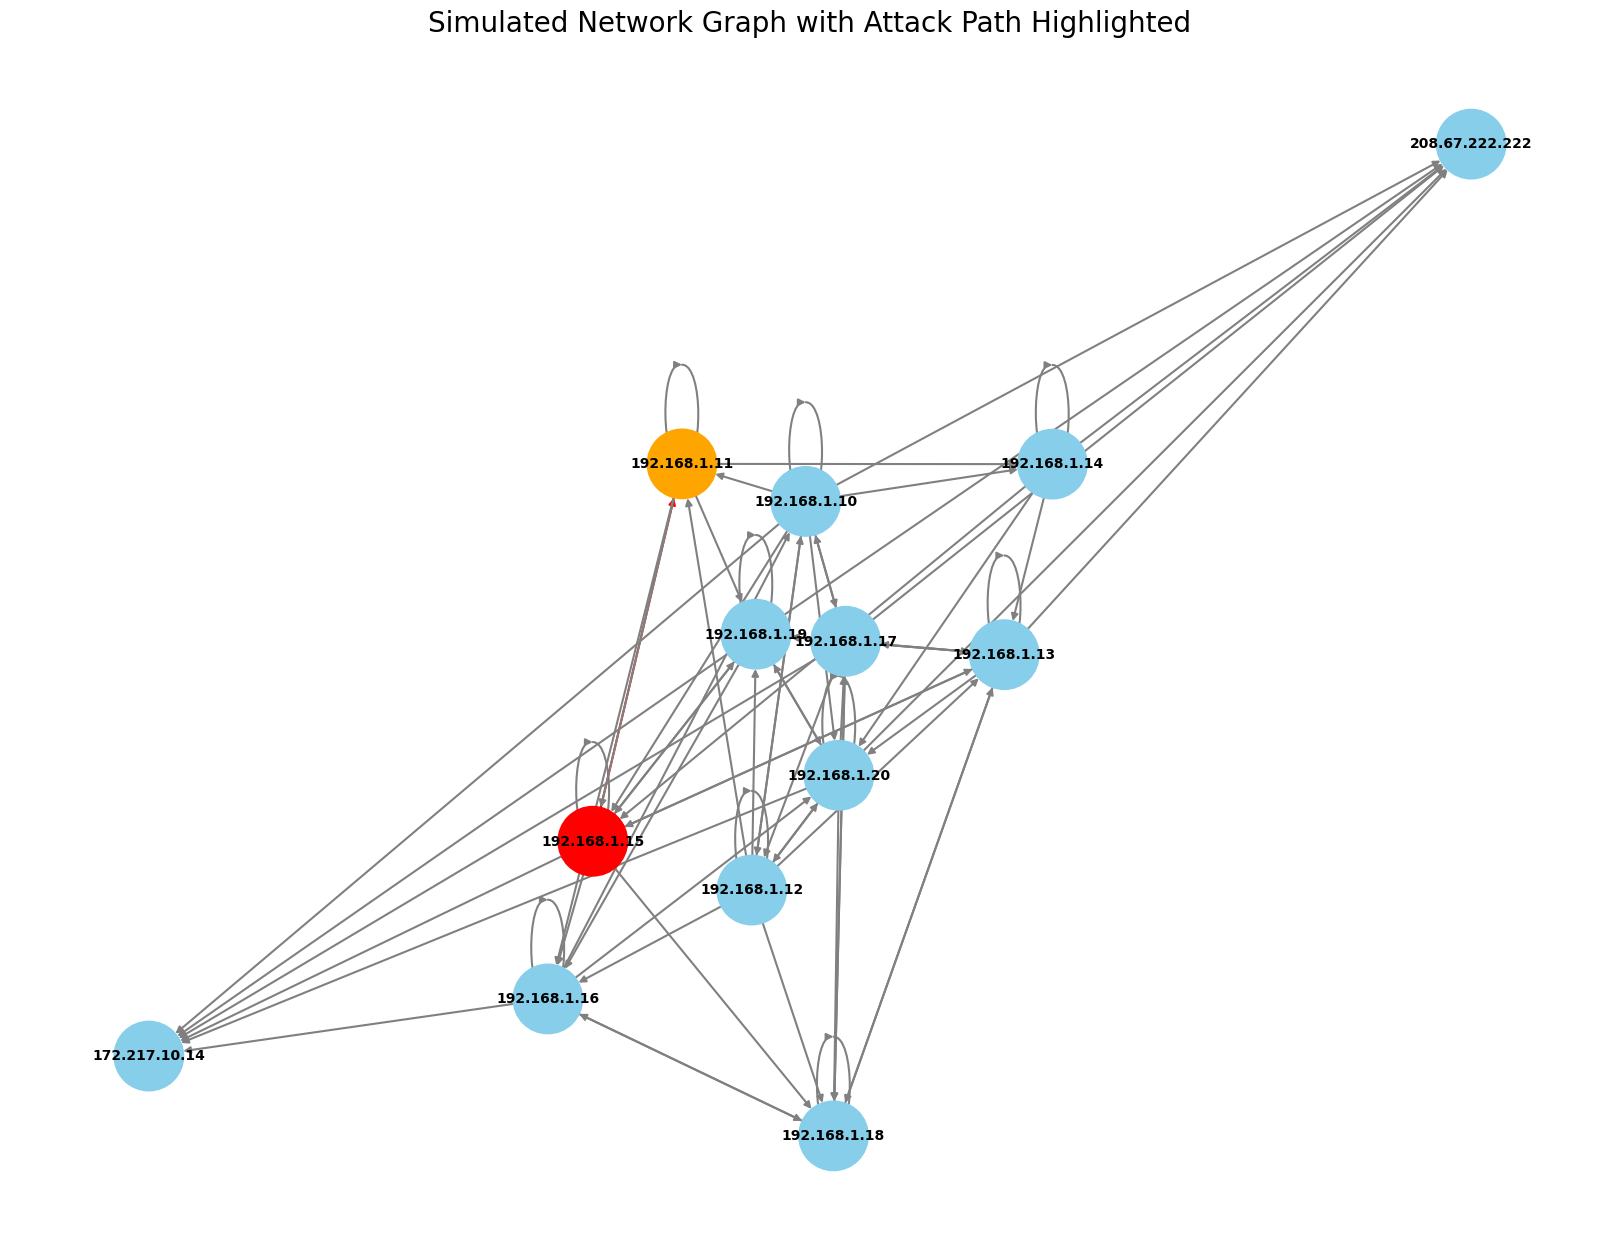

In [ ]:
INTERNAL_IPS = [f'192.168.1.{i}' for i in range(10, 21)]
ATTACKER_IP = INTERNAL_IPS[5] # 192.168.1.15
VICTIM_IP = INTERNAL_IPS[1]   # 192.168.1.11

# --- Log Generation (Unchanged) ---
def generate_conn_logs(num_normal=100, num_attack_attempts=5, num_attack_success=1):
    # This function remains the same...
    # (Code is collapsed for brevity)
    external_ips = ['172.217.10.14', '208.67.222.222']
    base_ts = int(time.time())
    log_entries = ["\t".join(FIELD_NAMES)] 
    def generate_log_line(orig_h, orig_p, resp_h, resp_p, proto, service, duration, conn_state, history, current_ts):
        uid = f'C{random.randint(100000, 999999)}'
        ts_str = f'{current_ts:.3f}'
        return "\t".join(map(str, [ts_str, uid, orig_h, orig_p, resp_h, resp_p, proto, service, duration, conn_state, history]))
    for i in range(num_normal):
        current_ts = base_ts + i * random.uniform(0.1, 5.0)
        orig_h, resp_h = random.choice(INTERNAL_IPS), random.choice(INTERNAL_IPS + external_ips)
        if resp_h in external_ips:
            resp_p, service = random.choice([(443, 'ssl'), (53, 'dns')]); proto = 'tcp' if resp_p == 443 else 'udp'
            duration = round(random.uniform(0.1, 60.0), 3) if resp_p == 443 else 0.000
            conn_state, history = ('SF', 'CcdDa') if resp_p == 443 else ('SHR', 'Dq')
        else:
            resp_p, service = random.choice([(22, 'ssh'), (3389, 'rdp'), (445, 'smb')])
            proto, duration, conn_state, history = 'tcp', round(random.uniform(1.0, 120.0), 3), 'SF', 'CcdD'
        orig_p = random.randint(30000, 65535)
        log_entries.append(generate_log_line(orig_h, orig_p, resp_h, resp_p, proto, service, duration, conn_state, history, current_ts))
    attack_ts = base_ts + num_normal * 1.5 
    for i in range(num_attack_attempts):
        current_ts = attack_ts + i * random.uniform(0.001, 0.5); target_port = random.choice([21, 23, 135, 3389, 8080]) 
        conn_state, history = random.choice([('S0', 'S'), ('REJ', 'R')])
        log_entries.append(generate_log_line(ATTACKER_IP, random.randint(40000, 50000), VICTIM_IP, target_port, 'tcp', '-', 0.000, conn_state, history, current_ts))
    for i in range(num_attack_success):
        current_ts = attack_ts + num_attack_attempts * 0.5 + random.uniform(0.1, 1.0)
        success_port, service = random.choice([(22, 'ssh'), (3389, 'rdp')])
        log_entries.append(generate_log_line(ATTACKER_IP, random.randint(40000, 50000), VICTIM_IP, success_port, 'tcp', service, round(random.uniform(5.0, 30.0), 3), 'SF', 'CcdD', current_ts))
    with open(LOG_FILE, 'w') as f: f.write('\n'.join(log_entries))
    print(f"Log Generation Complete: Saved {len(log_entries) - 1} entries to {LOG_FILE}")

# --- FIX 1: More specific late-stage attack labeling ---
def map_to_attack_ttp(row):
    props = {"early_stage": False, "late_stage": False, "ttp_tag": "Normal"}
    is_scanning = (row['conn_state'] in ('S0', 'REJ')) and \
                  (row['id.orig_h'] == ATTACKER_IP) and \
                  (row['id.resp_h'] == VICTIM_IP)
    if is_scanning:
        props.update({"early_stage": True, "ttp_tag": "T1046:NetworkServiceDiscovery"})
    
    is_successful_pivot = (row['conn_state'] == 'SF') and \
                          (row['id.orig_h'] == ATTACKER_IP) and \
                          (row['id.resp_h'] == VICTIM_IP) and \
                          (row['id.resp_p'] in (22, 3389)) # Port check added
    if is_successful_pivot:
        props.update({"late_stage": True, "ttp_tag": "T1021:RemoteServices"})
        
    return props

# --- Graph Building (Unchanged) ---
def build_graph_from_logs_optimized(driver):
    # This function remains the same...
    # (Code is collapsed for brevity)
    print(f"\nBuilding graph from {LOG_FILE}...")
    df = pd.read_csv(LOG_FILE, sep='\t', header=0, names=FIELD_NAMES, skiprows=[1], on_bad_lines='skip', engine='python').copy()
    df['ts'], df['duration'], df['id.resp_p'] = pd.to_numeric(df['ts']), pd.to_numeric(df['duration']), pd.to_numeric(df['id.resp_p'])
    with driver.session() as session:
        session.run("MATCH (n) DETACH DELETE n")
        print("Database cleared. Starting fresh graph build.")
        all_ips = pd.concat([df['id.orig_h'], df['id.resp_h']]).unique().tolist()
        print(f"Creating {len(all_ips)} unique IP nodes in a single transaction...")
        node_query = "UNWIND $ip_list AS ip MERGE (n:IP {address: ip})"
        session.run(node_query, ip_list=all_ips)
        print("Creating relationships and applying ATT&CK tags in a single transaction...")
        relationship_data = []
        for index, row in df.iterrows():
            record = row.to_dict(); record.update(map_to_attack_ttp(row)); relationship_data.append(record)
        relationship_query = """
        UNWIND $rows AS row
        MATCH (orig:IP {address: row['id.orig_h']}), (resp:IP {address: row['id.resp_h']})
        CREATE (orig)-[:CONNECTS {
            timestamp: row.ts, duration: row.duration, protocol: row.proto,
            port: row['id.resp_p'], state: row.conn_state, ttp_tag: row.ttp_tag,
            is_attack_early: row.early_stage, is_attack_late: row.late_stage
        }]->(resp)
        """
        session.run(relationship_query, rows=relationship_data)
        print(f"Neo4j graph construction complete. {len(df)} connections processed.")

# --- Hypothesis Test (Unchanged) ---
def test_thesis_hypothesis(driver):
    # This function remains the same...
    # (Code is collapsed for brevity)
    print("\n--- Starting Thesis Hypothesis Test ---")
    with driver.session() as session:
        session.run("CALL gds.graph.drop('thesisGraph', false)")
        print("1. Projecting graph into GDS...")
        session.run("CALL gds.graph.project('thesisGraph', 'IP', 'CONNECTS')")
        print("2. Generating node embeddings with FastRP...")
        session.run("CALL gds.fastRP.mutate('thesisGraph', {embeddingDimension: 128, mutateProperty: 'embedding'})")
        session.run("CALL gds.graph.writeNodeProperties('thesisGraph', ['embedding'], ['IP'])")
        print("3. Fetching embeddings for correlation analysis...")
        early_result = session.run("MATCH (a:IP)-[r:CONNECTS {is_attack_early: true}]->(v:IP) RETURN a.embedding AS embedding LIMIT 1").single()
        late_result = session.run("MATCH (a:IP)-[r:CONNECTS {is_attack_late: true}]->(v:IP) RETURN a.embedding AS embedding LIMIT 1").single()
        if not early_result or not late_result:
            print("Could not find attacker embeddings. Aborting test.")
            return
        early_embedding = np.array(early_result['embedding']).reshape(1, -1)
        late_embedding = np.array(late_result['embedding']).reshape(1, -1)
        similarity_score = cosine_similarity(early_embedding, late_embedding)[0][0]
        print("\n--- HYPOTHESIS TEST RESULTS ---")
        print(f"Cosine Similarity between Early and Late-Stage Attacker Embeddings: {similarity_score:.4f}")
        if similarity_score > 0.85:
            print("Result: High correlation found. The hypothesis is strongly supported by this simulation.")
        else:
            print("Result: Low correlation found. The hypothesis is not supported by this simulation.")
        session.run("CALL gds.graph.drop('thesisGraph', false)")

# --- Verification (Unchanged) ---
def run_verification_query(driver):
    # This function remains the same...
    # (Code is collapsed for brevity)
    print("\n--- Automated Verification: Finding Attack Path ---")
    query = "MATCH (a:IP)-[r:CONNECTS {is_attack_late: TRUE}]->(v:IP) RETURN a.address AS attacker_ip, v.address AS victim_ip, r.port AS port"
    with driver.session() as session:
        result = session.run(query).data()
        if result:
            for record in result:
                print(f"Attack Detected: {record['attacker_ip']} -> {record['victim_ip']} on port {record['port']}")
        else:
            print("Verification Failed: No late-stage attack path found in the graph.")

# --- FIX 2: Enhanced visualization to show the full graph context ---
def visualize_attack_graph(driver):
    """Fetches the entire graph and highlights the attack path."""
    print("\n--- Generating Graph Visualization ---")
    
    # Query to fetch ALL nodes and relationships
    query = "MATCH (a:IP)-[r:CONNECTS]->(v:IP) RETURN a.address AS source, v.address AS target, r.is_attack_late AS is_attack"
    with driver.session() as session:
        results = session.run(query).data()

    if not results:
        print("No data to visualize."); return

    G = nx.DiGraph()
    attack_edges = []
    for record in results:
        G.add_edge(record['source'], record['target'])
        if record['is_attack']:
            attack_edges.append((record['source'], record['target']))
    
    # Define node colors
    node_colors = ['red' if node == ATTACKER_IP else 'orange' if node == VICTIM_IP else 'skyblue' for node in G.nodes()]
    # Define edge colors
    edge_colors = ['red' if edge in attack_edges else 'gray' for edge in G.edges()]
    
    pos = nx.spring_layout(G, k=0.5, iterations=50) # Use a layout that spreads nodes out
    plt.figure(figsize=(16, 12))
    
    nx.draw(G, pos, with_labels=True, node_color=node_colors, edge_color=edge_colors,
            node_size=2500, font_size=10, font_weight='bold', width=1.5, arrows=True)
    
    plt.title("Simulated Network Graph with Attack Path Highlighted", size=20)
    plt.savefig("attack_graph.png")
    print("Visualization saved to attack_graph.png")

# --- Main Execution (Unchanged) ---
if __name__ == "__main__":
    driver = None
    try:
        generate_conn_logs()
        driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
        driver.verify_connectivity()
        build_graph_from_logs_optimized(driver)
        test_thesis_hypothesis(driver)
        run_verification_query(driver)
        visualize_attack_graph(driver)
    except Exception as e:
        print(f"An error occurred: {e}")
    finally:
        if driver:
            driver.close()